course: 5DATA001C.2 Machine Learning and Data Mining

Author: J B A S Nethmina

Student_id: 20230384(uow - w2120633)

peer_reviewer :G.M.K.T Thaksara

Peer Review Meeting : week 8

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_curve, auc,accuracy_score, roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import plotly.express as px
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/loan_approval_data (1).csv')
df.head()

,id,age,income,home_ownership,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan
0,35437,21.0,12000,OWN,0,EDUCATION,15000,6.99,0.12,N,4,0,-2426900
1,53756,21.0,13200,OWN,2,EDUCATION,25000,16.77,0.19,Y,3,0,-111739
2,42205,23.0,9600,RENT,5,MEDICAL,30000,12.42,0.31,N,3,0,-89000
3,19180,40.0,182004,RENT,3,EDUCATION,35000,8.00,0.19,N,11,0,35000
4,28072,40.0,90000,MORTGAGE,3,HOMEIMPROVEMENT,35000,12.42,0.39,N,14,0,35000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       58645 non-null  int64  
 1   age                      58639 non-null  float64
 2   income                   58645 non-null  int64  
 3   home_ownership           58645 non-null  object 
 4   emplyment_length         58645 non-null  int64  
 5   loan_intent              58645 non-null  object 
 6   loan_amount              58645 non-null  int64  
 7   loan_interest_rate       58634 non-null  float64
 8   loan_income_ratio        58645 non-null  float64
 9   payment_default_on_file  58640 non-null  object 
 10  credit_history_length    58645 non-null  int64  
 11  loan_approval_status     58645 non-null  int64  
 12  max_allowed_loan         58645 non-null  int64  
dtypes: float64(3), int64(7), object(3)
memory usage: 5.8+ MB


In [ ]:
df.isnull().sum()

,0
id,0
age,6
income,0
home_ownership,0
emplyment_length,0
loan_intent,0
loan_amount,0
loan_interest_rate,11
loan_income_ratio,0
payment_default_on_file,5


In [ ]:
# Fill numeric columns with median
df['age'].fillna(df['age'].median(), inplace=True)
df['loan_interest_rate'].fillna(df['loan_interest_rate'].median(), inplace=True)

# Fill categorical column with mode
df['payment_default_on_file'].fillna(df['payment_default_on_file'].mode()[0], inplace=True)

/tmp/ipykernel_19615/2077169524.py:2: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



/tmp/ipykernel_19615/2077169524.py:3: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' 

In [ ]:
df.isnull().sum()

,0
id,0
age,0
income,0
home_ownership,0
emplyment_length,0
loan_intent,0
loan_amount,0
loan_interest_rate,0
loan_income_ratio,0
payment_default_on_file,0


In [ ]:
df_model = df.drop(columns=['id', 'max_allowed_loan'])


In [ ]:
le = LabelEncoder()
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

In [ ]:
df_model.fillna(df_model.median(), inplace=True)


In [ ]:
X = df_model.drop(columns=['loan_approval_status'])
y = df_model['loan_approval_status']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
print("Training set class distribution:")
print(y_train.value_counts(normalize=True))



Training set class distribution:
loan_approval_status
0    0.857618
1    0.142382
Name: proportion, dtype: float64


In [ ]:
print("\nTest set class distribution:")
print(y_test.value_counts(normalize=True))


Test set class distribution:
loan_approval_status
0    0.857618
1    0.142382
Name: proportion, dtype: float64


In [ ]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)


In [ ]:
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")


Train: 46916 | Test: 11729


In [ ]:
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_sc, y_train)
lr_pred = lr_model.predict(X_test_sc)
lr_prob = lr_model.predict_proba(X_test_sc)[:, 1]
print(" Logistic Regression")

 Logistic Regression


In [ ]:
print(f"   Accuracy : {accuracy_score(y_test, lr_pred):.4f}")
print(f"   ROC-AUC  : {roc_auc_score(y_test, lr_prob):.4f}\n")

   Accuracy : 0.8902
   ROC-AUC  : 0.8714



In [ ]:
nb_model = GaussianNB()
nb_model.fit(X_train_sc, y_train)
nb_pred = nb_model.predict(X_test_sc)
nb_prob = nb_model.predict_proba(X_test_sc)[:, 1]
print(" Naïve Bayes")

 Naïve Bayes


In [ ]:
print(f"   Accuracy : {accuracy_score(y_test, nb_pred):.4f}")
print(f"   ROC-AUC  : {roc_auc_score(y_test, nb_prob):.4f}\n")



   Accuracy : 0.8493
   ROC-AUC  : 0.8548



In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_sc, y_train)
knn_pred = knn_model.predict(X_test_sc)
knn_prob = knn_model.predict_proba(X_test_sc)[:, 1]
print("KNN")

KNN


In [ ]:
print(f"   Accuracy : {accuracy_score(y_test, knn_pred):.4f}")
print(f"   ROC-AUC  : {roc_auc_score(y_test, knn_prob):.4f}")

   Accuracy : 0.9142
   ROC-AUC  : 0.8552


In [ ]:
#confusion matrix - logisitic regression

cm = confusion_matrix(y_test, lr_pred)
fig = px.imshow(cm, text_auto=True,
                x=['Rejected', 'Approved'],
                y=['Rejected', 'Approved'],
                title='Confusion Matrix – Logistic Regression')
fig.show()

In [ ]:
#confusion_matrix_NB

Cm_NB = confusion_matrix(y_test,nb_pred)

fig = px.imshow(Cm_NB, text_auto=True,
                x=['Rejected', 'Approved'],
                y=['Rejected', 'Approved'],
                title='Confusion Matrix – Logistic Regression')
fig.show()


In [ ]:
#confusion_matrix -KNN

Cm_KNN = confusion_matrix(y_test,knn_pred)
fig = px.imshow(Cm_KNN, text_auto=True,
                x=['Rejected', 'Approved'],
                y=['Rejected', 'Approved'],
                title='Confusion Matrix – Logistic Regression')
fig.show()

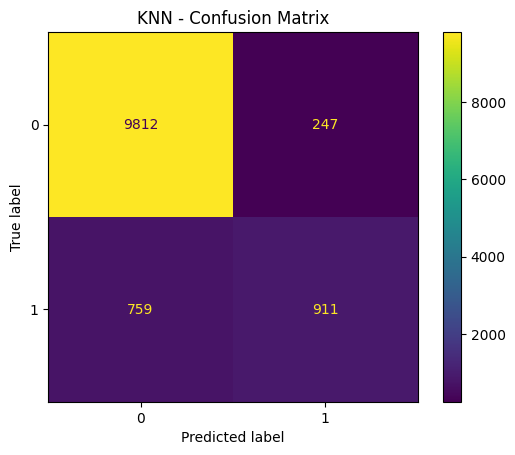

In [ ]:
# Confusion Matrix
cm_knn = confusion_matrix(y_test,knn_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn)
disp.plot()
plt.title("KNN - Confusion Matrix")
plt.show()

In [ ]:
print("\nclassification_report-LR\n")

print(classification_report(y_test, lr_pred,
      target_names=['Rejected', 'Approved']))



classification_report-LR

              precision    recall  f1-score   support

    Rejected       0.90      0.97      0.94     10059
    Approved       0.72      0.38      0.50      1670

    accuracy                           0.89     11729
   macro avg       0.81      0.68      0.72     11729
weighted avg       0.88      0.89      0.88     11729



In [ ]:
print("\nclassification_report-NB\n")

print(classification_report(y_test, nb_pred,
      target_names=['Rejected', 'Approved']))


classification_report-NB

              precision    recall  f1-score   support

    Rejected       0.93      0.89      0.91     10059
    Approved       0.48      0.60      0.53      1670

    accuracy                           0.85     11729
   macro avg       0.70      0.75      0.72     11729
weighted avg       0.87      0.85      0.86     11729



In [ ]:
print("\nclassification_report-KNN\n")

print(classification_report(y_test, knn_pred,
    target_names = ['Rejected','Approved']))


classification_report-KNN

              precision    recall  f1-score   support

    Rejected       0.93      0.98      0.95     10059
    Approved       0.79      0.55      0.64      1670

    accuracy                           0.91     11729
   macro avg       0.86      0.76      0.80     11729
weighted avg       0.91      0.91      0.91     11729



In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear']
}

grid = GridSearchCV(
    estimator=lr_model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,        # use all CPU (faster)
    verbose=1         # shows progress (good evidence)
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Cross-validation Score:", grid.best_score_)

best_model = grid.best_estimator_

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Parameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
Best Cross-validation Score: 0.882620098255002


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



In [ ]:
param_grid = {'n_neighbors': [3, 5, 7, 11]}
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid.fit(X_train_sc, y_train)
print("Best:", grid.best_params_)

Best: {'n_neighbors': 11}


In [ ]:
X_train = X_train.values
X_test = X_test.values

In [ ]:
# BEFORE tuning (original LR model)
y_pred_before = lr_model.predict(X_test)

# AFTER tuning (best model from GridSearch)
y_pred_after = best_model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LogisticRegression was fitted with feature names



In [ ]:
cm_before = confusion_matrix(y_test, y_pred_before)

fig_before = px.imshow(
    cm_before,
    text_auto=True,
    x=['Rejected', 'Approved'],
    y=['Rejected', 'Approved'],
    color_continuous_scale='Oranges',
    title='Confusion Matrix – Logistic Regression (BEFORE Tuning)'
)

fig_before.update_layout(xaxis_title="Predicted", yaxis_title="Actual")
fig_before.show()

In [ ]:
cm_after = confusion_matrix(y_test, y_pred_after)

fig_after = px.imshow(
    cm_after,
    text_auto=True,
    x=['Rejected', 'Approved'],
    y=['Rejected', 'Approved'],
    color_continuous_scale='Purples',
    title='Confusion Matrix – Logistic Regression (AFTER Tuning)'
)

fig_after.update_layout(xaxis_title="Predicted", yaxis_title="Actual")
fig_after.show()

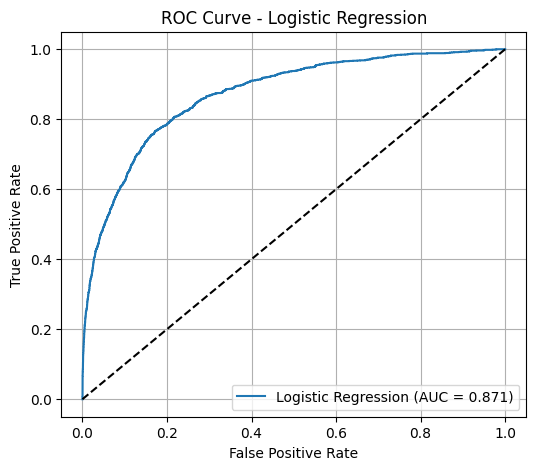

In [ ]:
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
lr_auc = auc(lr_fpr, lr_tpr)

plt.figure(figsize=(6,5))
plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {lr_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')  # random line

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.grid()
plt.show()

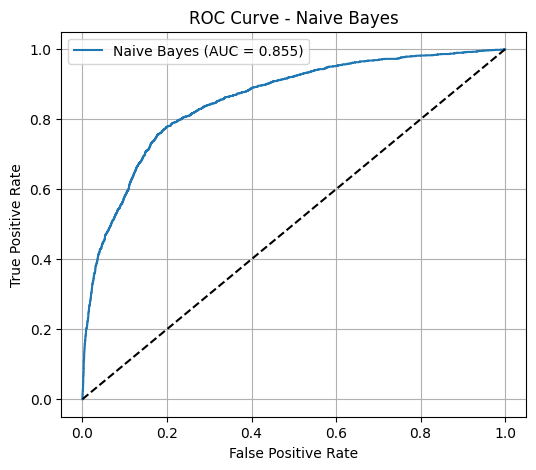

In [ ]:
nb_fpr, nb_tpr, _ = roc_curve(y_test, nb_prob)
nb_auc = auc(nb_fpr, nb_tpr)

plt.figure(figsize=(6,5))
plt.plot(nb_fpr, nb_tpr, label=f'Naive Bayes (AUC = {nb_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Naive Bayes')
plt.legend()
plt.grid()
plt.show()

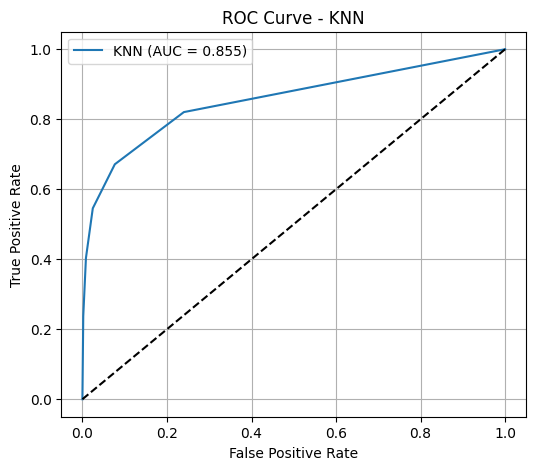

In [ ]:
knn_fpr, knn_tpr, _ = roc_curve(y_test, knn_prob)
knn_auc = auc(knn_fpr, knn_tpr)

plt.figure(figsize=(6,5))
plt.plot(knn_fpr, knn_tpr, label=f'KNN (AUC = {knn_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - KNN')
plt.legend()
plt.grid()
plt.show()